In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


sys.path.append('..')

from src.kitti_utils import parse_timestamps, get_frame_interval, load_kitti_calib
from src.optical_flow import compute_sparse_flow
from src.geometry import validate_with_cross_ratio


BASE_PATH = "D:/reyci/Politecnico di Milano/2025-2/Image Analysis and CV/Project/Code/IACV-Depth-Estimation-from-Temporal-Stereo-in-Monocular-Driving-Sequences-/data/raw/2011_09_26_drive_0001_extract"
IMG_PATH = os.path.join(BASE_PATH, "image_02/data")
CALIB_CAM_PATH = os.path.join(BASE_PATH, "calib/calib_cam_to_cam.txt")
CALIB_VELO_PATH = os.path.join(BASE_PATH, "calib/calib_velo_to_cam.txt")

# Select a sequence of 3 consecutive frames
idx_t0 = 50
idx_t1 = 51
idx_t2 = 52

img0 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t0:010d}.png"))
img1 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t1:010d}.png"))
img2 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t2:010d}.png"))

print(f"Loaded frames: {idx_t0}, {idx_t1}, {idx_t2}")

Loaded frames: 50, 51, 52


In [8]:
# 1. Obtain initial points and their optical flow from img0 to img1
p0, p1 = compute_sparse_flow(img0, img1)

# 2. Re-project p1 toward img2 to obtain p2 (chained tracking)
# Lucas-Kanade parameters for the second step
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

p2, status, err = cv2.calcOpticalFlowPyrLK(
    cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY),
    p1.astype(np.float32),
    None,
    **lk_params
)

# 3. Filter points that were lost during tracking
valid_mask = status.flatten() == 1
p0_v, p1_v, p2_v = p0[valid_mask], p1[valid_mask], p2[valid_mask]

print(f"Successfully tracked points across all 3 frames: {len(p0_v)}")

Successfully tracked points across all 3 frames: 97


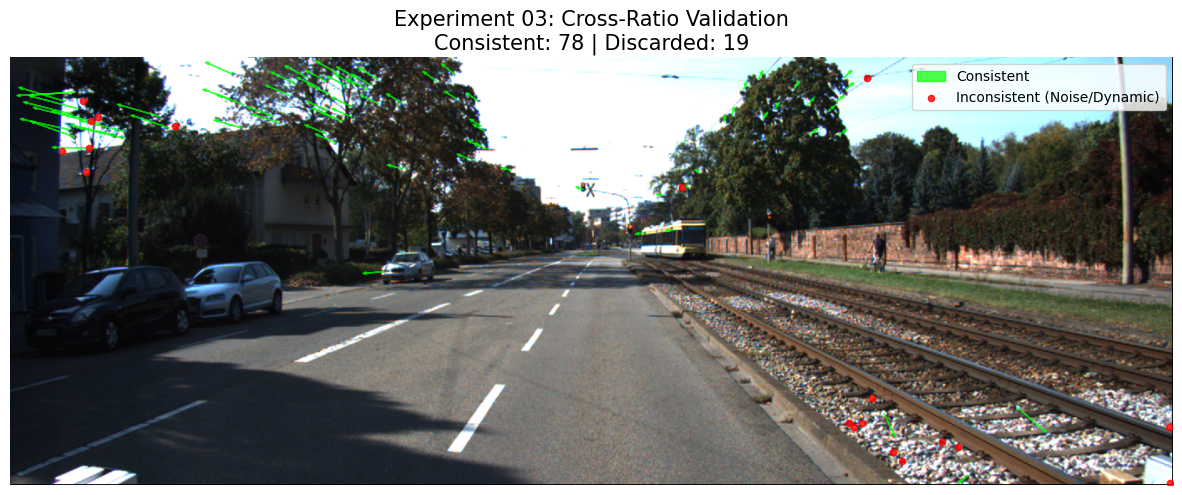

Temporal Reliability Index: 80.41%


In [9]:
# 1. Validate temporal consistency
# If the expansion between p0-p1 and p1-p2 is not harmonic, the point is discarded
mask_consistent = validate_with_cross_ratio(p0_v, p1_v, p2_v, tti_est=None)

p0_final = p0_v[mask_consistent]
p1_final = p1_v[mask_consistent]
p2_final = p2_v[mask_consistent]

p0_noisy = p0_v[~mask_consistent]

# 2. Visualization
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img0, cv2.COLOR_BGR2RGB))

# Draw consistent points (Green)
for i in range(len(p0_final)):
    plt.arrow(
        p0_final[i, 0], p0_final[i, 1],
        p2_final[i, 0] - p0_final[i, 0],
        p2_final[i, 1] - p0_final[i, 1],
        color='lime',
        head_width=3,
        alpha=0.7,
        label='Consistent' if i == 0 else ""
    )

# Draw noisy points (Red)
for i in range(len(p0_noisy)):
    plt.scatter(
        p0_noisy[i, 0],
        p0_noisy[i, 1],
        color='red',
        s=20,
        alpha=0.8,
        label='Inconsistent (Noise/Dynamic)' if i == 0 else ""
    )

plt.title(
    f"Experiment 03: Cross-Ratio Validation\n"
    + f"Consistent: {len(p0_final)} | Discarded: {len(p0_noisy)}",
    fontsize=15
)

plt.legend()
plt.axis('off')
plt.show()

# Statistics for the report
reliability = (len(p0_final) / len(p0_v)) * 100
print(f"Temporal Reliability Index: {reliability:.2f}%")